In [2]:
import matplotlib.pyplot as plt
import librosa
import numpy as np
from IPython.display import Audio, display

import ruptures as rpt  # our packageimport matplotlib.pyplot as plt
import librosa
import numpy as np
from IPython.display import Audio, display

import ruptures as rpt  # our package

In [3]:
def fig_ax(figsize=(15, 5), dpi=150):
    """Return a (matplotlib) figure and ax objects with given size."""
    return plt.subplots(figsize=figsize, dpi=dpi)


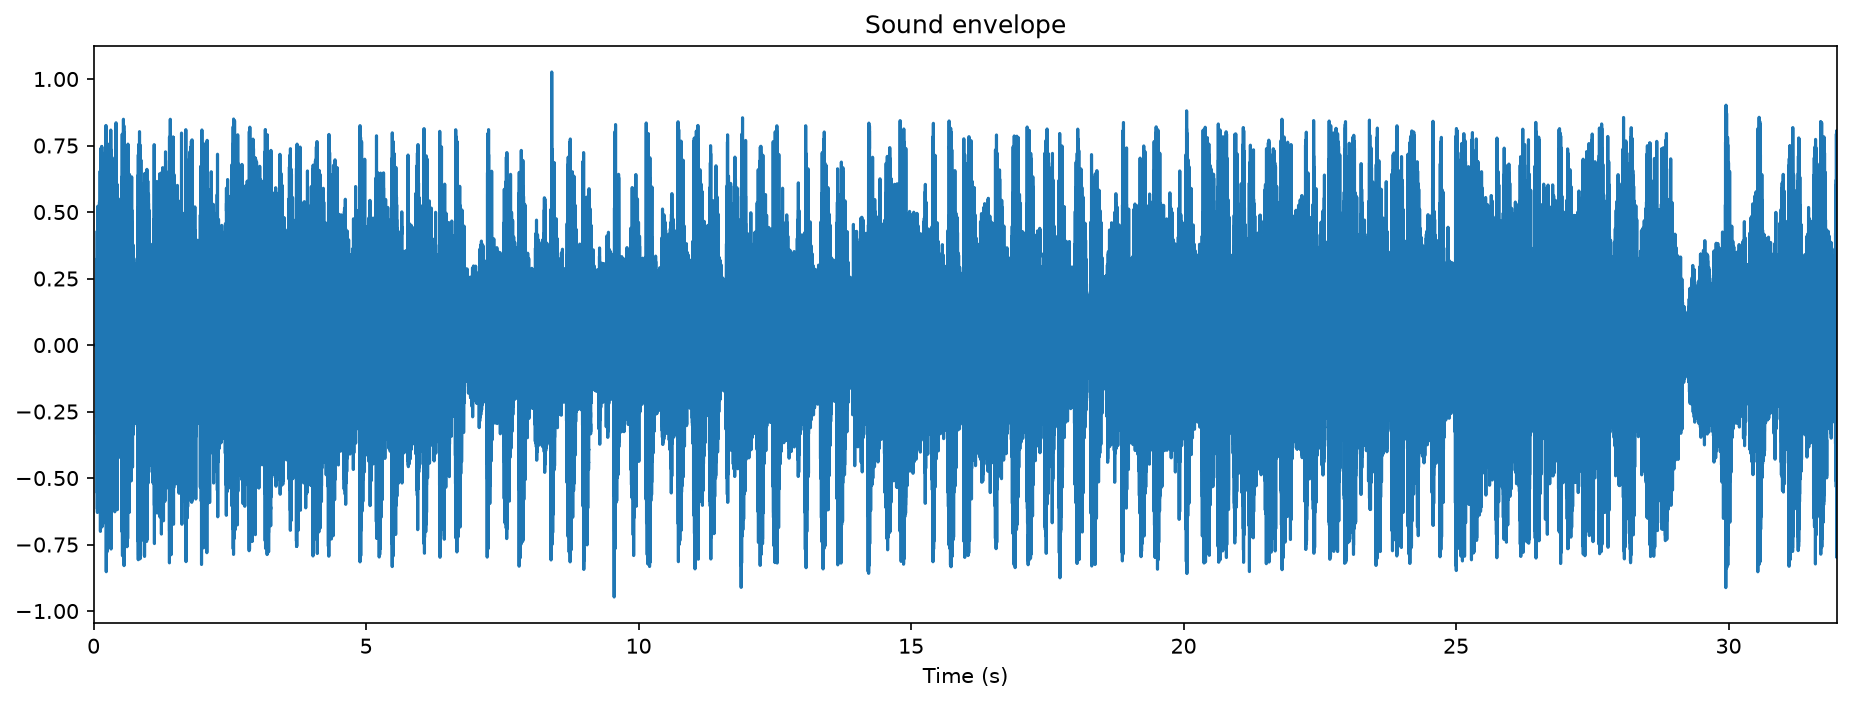

In [4]:
duration = 32  # in seconds
# signal, sampling_rate = librosa.load("D:/Intrest/radio_listener/streams/radio_Radio Mirchi Hindi/2026-09-14_20-36-06.mp3")
signal, sampling_rate = librosa.load("D:/Intrest/radio_listener/streams/radio_Mirchi Love/2026-09-14_20-37-55.mp3")

# listen to the music
display(Audio(data=signal, rate=sampling_rate))

# look at the envelope
fig, ax = fig_ax()
ax.plot(np.arange(signal.size) / sampling_rate, signal)
ax.set_xlim(0, signal.size / sampling_rate)
ax.set_xlabel("Time (s)")
_ = ax.set(title="Sound envelope")


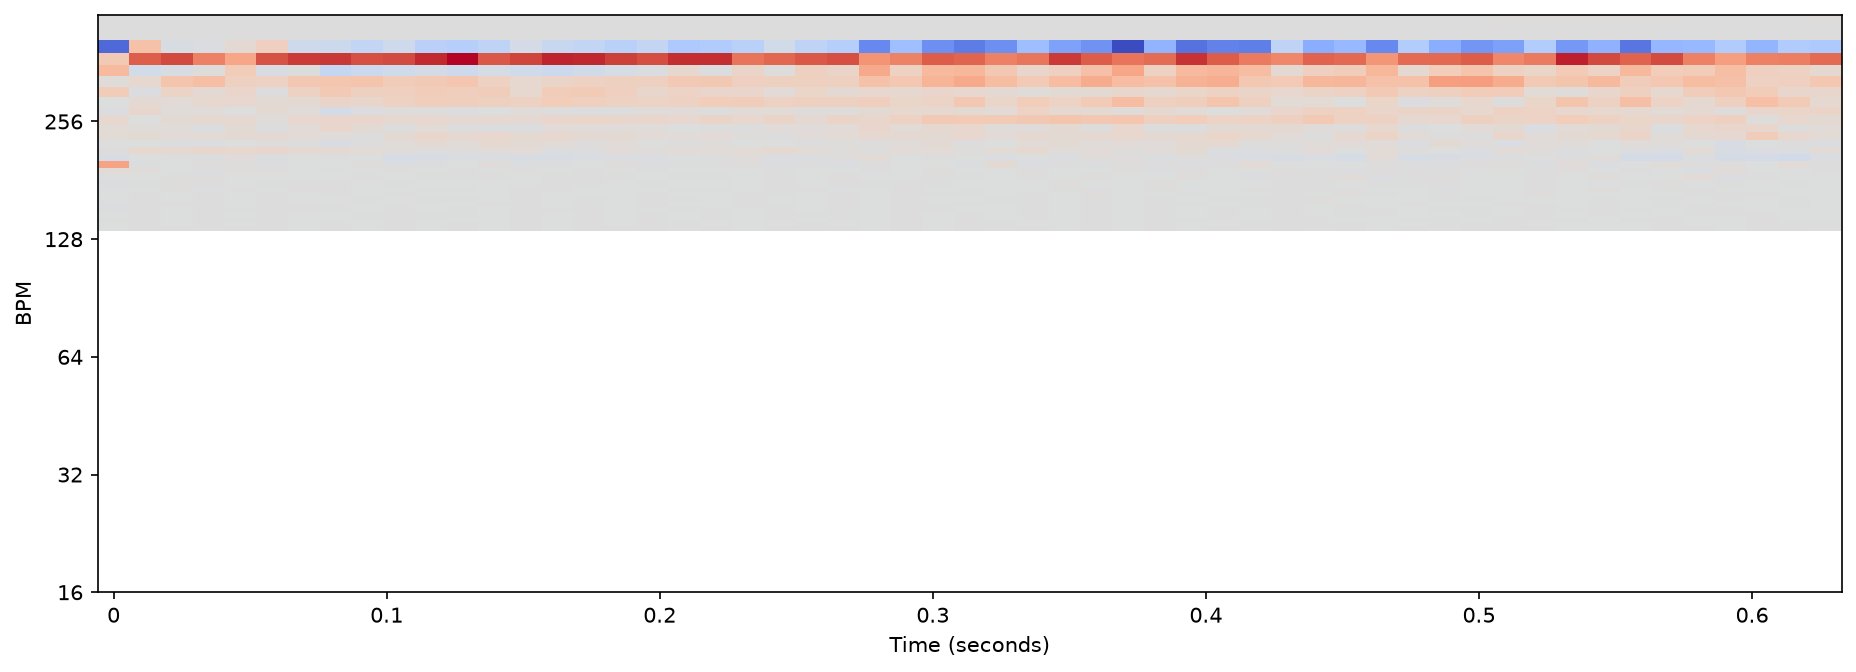

In [6]:
# Compute the onset strength
# hop_length_tempo = 256
hop_length_tempo = 256
# Separate harmonics and percussives into two waveforms
y_harmonic, y_percussive = librosa.effects.hpss(signal)

# Beat track on the percussive signal
tempo, beat_frames = librosa.beat.beat_track(y=y_percussive,
                                             sr=sampling_rate)

# Compute MFCC features from the raw signal
mfcc = librosa.feature.mfcc(y=signal, sr=sampling_rate, hop_length=hop_length_tempo, n_mfcc=13)

# And the first-order differences (delta features)
mfcc_delta = librosa.feature.delta(mfcc)

# Stack and synchronize between beat events
# This time, we'll use the mean value (default) instead of median
beat_mfcc_delta = librosa.util.sync(np.vstack([mfcc, mfcc_delta]),
                                    beat_frames)
# Compute chroma features from the harmonic signal
chromagram = librosa.feature.chroma_cqt(y=y_harmonic,
                                        sr=sampling_rate)

# Aggregate chroma features between beat events
# We'll use the median value of each feature between beat frames
beat_chroma = librosa.util.sync(chromagram,
                                beat_frames,
                                aggregate=np.median)

# Finally, stack all beat-synchronous features together
beat_features = np.vstack([beat_chroma, beat_mfcc_delta])


# oenv = librosa.onset.onset_strength(
#     y=signal, sr=sampling_rate, hop_length=hop_length_tempo
# )
# # Compute the tempogram
# tempogram = librosa.feature.tempogram(
#     onset_envelope=oenv,
#     sr=sampling_rate,
#     hop_length=hop_length_tempo,
# )
# Display the tempogram
fig, ax = fig_ax()
_ = librosa.display.specshow(
    beat_features,
    ax=ax,
    hop_length=hop_length_tempo,
    sr=sampling_rate,
    x_axis="s",
    y_axis="tempo",
)


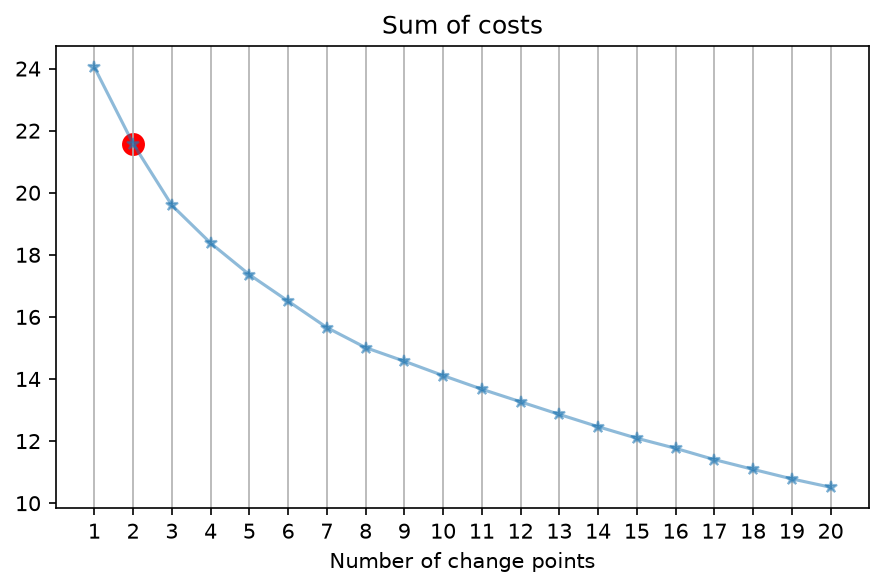

In [ ]:
# Choose detection method
min_segment_sec = 30
min_frames = int((min_segment_sec * sampling_rate) / hop_length_tempo) 
# algo = rpt.KernelCPD(kernel="rbf").fit(tempogram.T)
algo = rpt.KernelCPD(kernel="linear").fit(beat_features.T)

# Choose the number of changes (elbow heuristic)
n_bkps_max = 20  # K_max
# Start by computing the segmentation with most changes.
# After start, all segmentations with 1, 2,..., K_max-1 changes are also available for free.
_ = algo.predict(n_bkps_max)

array_of_n_bkps = np.arange(1, n_bkps_max + 1)


def get_sum_of_cost(algo, n_bkps) -> float:
    """Return the sum of costs for the change points `bkps`"""
    bkps = algo.predict(n_bkps=n_bkps)
    return algo.cost.sum_of_costs(bkps)


fig, ax = fig_ax((7, 4))
ax.plot(
    array_of_n_bkps,
    [get_sum_of_cost(algo=algo, n_bkps=n_bkps) for n_bkps in array_of_n_bkps],
    "-*",
    alpha=0.5,
)
ax.set_xticks(array_of_n_bkps)
ax.set_xlabel("Number of change points")
ax.set_title("Sum of costs")
ax.grid(axis="x")
ax.set_xlim(0, n_bkps_max + 1)

# Visually we choose n_bkps=5 (highlighted in red on the elbow plot)
n_bkps = 2
_ = ax.scatter([2], [get_sum_of_cost(algo=algo, n_bkps=2)], color="r", s=100)

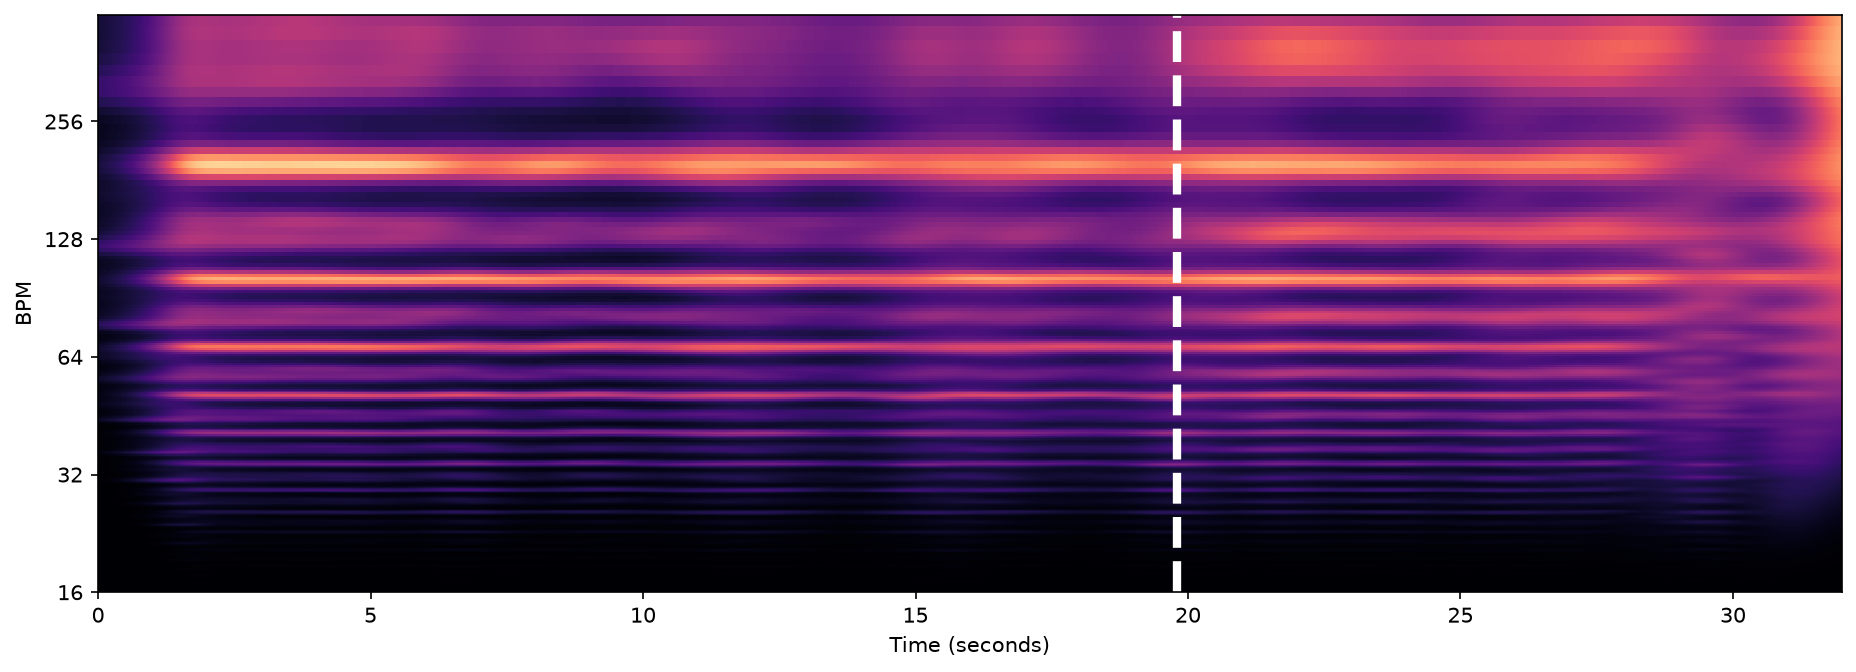

In [ ]:
# Segmentation
# bkps = algo.predict(n_bkps=n_bkps)
bkps = algo.predict(pen=250)
# Convert the estimated change points (frame counts) to actual timestamps
bkps_times = librosa.frames_to_time(bkps, sr=sampling_rate, hop_length=hop_length_tempo)

# Displaying results
fig, ax = fig_ax()
_ = librosa.display.specshow(
    tempogram,
    ax=ax,
    x_axis="s",
    y_axis="tempo",
    hop_length=hop_length_tempo,
    sr=sampling_rate,
)

for b in bkps_times[:-1]:
    ax.axvline(b, ls="--", color="white", lw=4)


In [ ]:
# Compute change points corresponding indexes in original signal
bkps_time_indexes = (sampling_rate * bkps_times).astype(int).tolist()

for segment_number, (start, end) in enumerate(
    rpt.utils.pairwise([0] + bkps_time_indexes), start=1
):
    segment = signal[start:end]
    print(f"Segment n°{segment_number} (duration: {segment.size/sampling_rate:.2f} s)")
    display(Audio(data=segment, rate=sampling_rate))


Segment n°1 (duration: 19.80 s)


Segment n°2 (duration: 12.20 s)
